In [4]:
import numpy as np
import pandas as pd
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from tabulate import tabulate


In [5]:
FEATURES = [
    "YEAR", "DAY_OF_MONTH", "DAY_OF_WEEK", "IS_WEEKEND",
    "CRS_DEP_TIME_MIN", "CRS_ARR_TIME_MIN",
    "CRS_DEP_SIN", "CRS_DEP_COS", "CRS_ARR_SIN", "CRS_ARR_COS", "DISTANCE",
    "OP_CARRIER_FREQ", "CARRIER_HIST_OTP",
    "ORIGIN_FREQ", "ORIGIN_HIST_OTP", "DEST_FREQ",
    "ROUTE_FREQ", "DEP_TIME_BLK_FREQ",
]

TARGET = "ARR_DEL15"
RANDOM_SEED = 42
VALIDATION_FRACTION = 0.10

train_path = "../data/processed/ml_track_a/ml_track_a_train.parquet"
test_path = "../data/processed/ml_track_a/ml_track_a_test.parquet"

df_train = pd.read_parquet(train_path)
df_test = pd.read_parquet(test_path)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)


Train shape: (1913300, 19)
Test shape : (522269, 19)


In [6]:
X_train = df_train[FEATURES].astype("float32")
y_train = df_train[TARGET].astype("int8")

X_test = df_test[FEATURES].astype("float32")
y_test = df_test[TARGET].astype("int8")

print("Features:", X_train.columns.tolist())


Features: ['YEAR', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'CRS_DEP_TIME_MIN', 'CRS_ARR_TIME_MIN', 'CRS_DEP_SIN', 'CRS_DEP_COS', 'CRS_ARR_SIN', 'CRS_ARR_COS', 'DISTANCE', 'OP_CARRIER_FREQ', 'CARRIER_HIST_OTP', 'ORIGIN_FREQ', 'ORIGIN_HIST_OTP', 'DEST_FREQ', 'ROUTE_FREQ', 'DEP_TIME_BLK_FREQ']


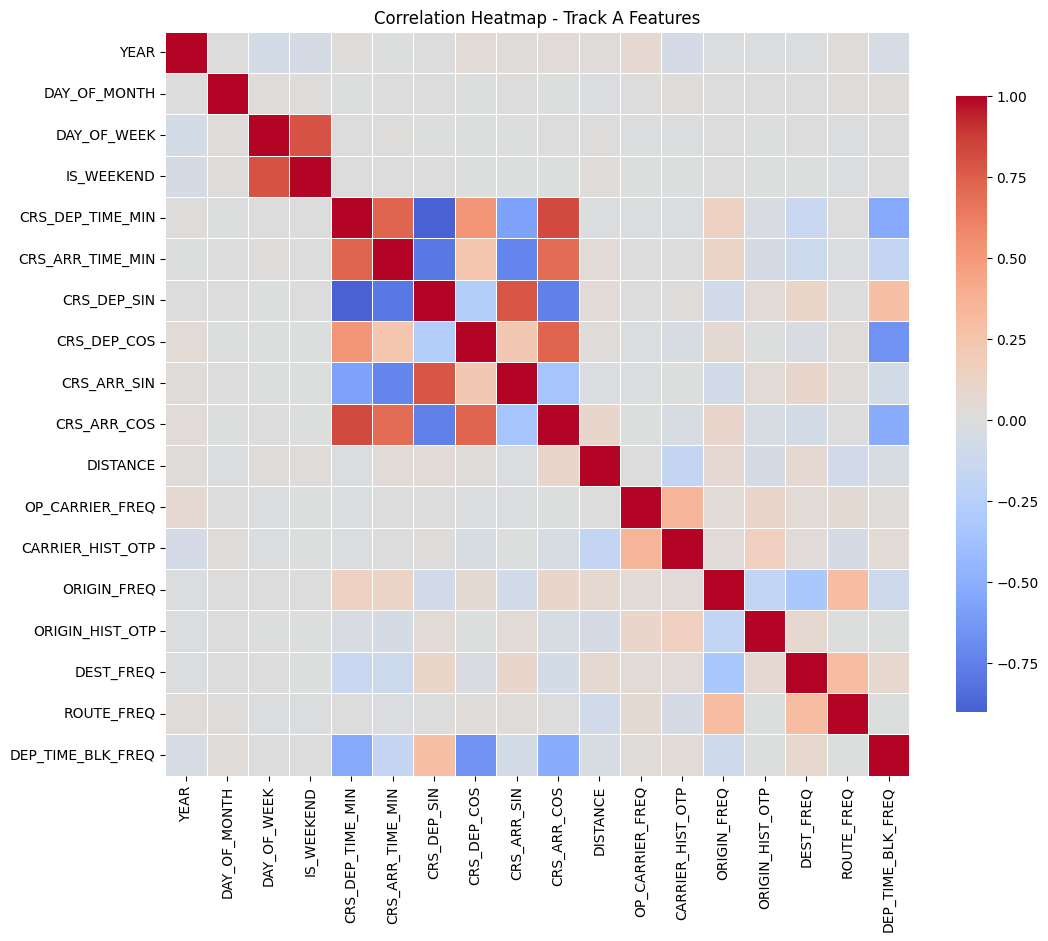

In [7]:
plt.figure(figsize=(12, 10))

corr = X_train.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap - Track A Features")
plt.show()


In [8]:
corr_target = df_train[FEATURES + [TARGET]].corr(numeric_only=True)[TARGET].sort_values(ascending=False)
print(corr_target.head(21))


ARR_DEL15            1.000000
YEAR                 0.116721
CRS_DEP_TIME_MIN     0.089406
CRS_ARR_COS          0.083369
CRS_ARR_TIME_MIN     0.077256
CRS_DEP_COS          0.035671
DISTANCE             0.019486
ORIGIN_FREQ          0.014452
IS_WEEKEND           0.012699
DAY_OF_WEEK          0.003808
ROUTE_FREQ          -0.002213
DEST_FREQ           -0.011938
OP_CARRIER_FREQ     -0.024169
DEP_TIME_BLK_FREQ   -0.036095
CRS_ARR_SIN         -0.069840
CARRIER_HIST_OTP    -0.070643
ORIGIN_HIST_OTP     -0.077811
DAY_OF_MONTH        -0.082888
CRS_DEP_SIN         -0.091525
Name: ARR_DEL15, dtype: float64


In [9]:
def evaluate_model(y_true, y_prob, threshold=0.5, model_name="Model"):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    print(model_name)
    print(f"Threshold: {threshold:.2f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc,
    }


def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


def best_threshold_from_validation(y_true, y_prob):
    best_threshold = 0.50
    best_f1 = -1.0

    for threshold in np.arange(0.20, 0.71, 0.02):
        y_pred = (y_prob >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_threshold = float(threshold)
            best_f1 = float(f1)

    return best_threshold


In [10]:
indices = np.arange(len(y_train))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VALIDATION_FRACTION,
    random_state=RANDOM_SEED,
    stratify=y_train,
)

X_fit = X_train.to_numpy(dtype=np.float32)[train_idx]
y_fit = y_train.to_numpy(dtype=np.float32)[train_idx]
X_val = X_train.to_numpy(dtype=np.float32)[val_idx]
y_val = y_train.to_numpy(dtype=np.int8)[val_idx]
X_test_np = X_test.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.int8)


Logistic Regression
Threshold: 0.48
Accuracy : 0.2183
Precision: 0.1916
Recall   : 0.9816
F1-score : 0.3206
ROC-AUC  : 0.6177

Confusion Matrix:
[[ 17701 406438]
 [  1807  96323]]


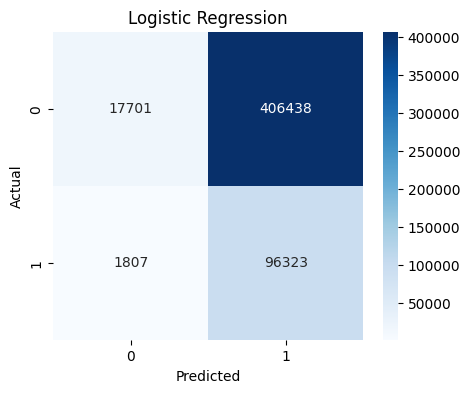

In [11]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ))
])

lr_pipeline.fit(X_fit, y_fit)

y_prob_lr_val = lr_pipeline.predict_proba(X_val)[:, 1]
lr_threshold = best_threshold_from_validation(y_val, y_prob_lr_val)

y_prob_lr = lr_pipeline.predict_proba(X_test_np)[:, 1]
y_pred_lr = (y_prob_lr >= lr_threshold).astype(int)

results_lr = evaluate_model(y_test_np, y_prob_lr, threshold=lr_threshold, model_name="Logistic Regression")
plot_cm(y_test_np, y_pred_lr, "Logistic Regression")


[LightGBM] [Info] Number of positive: 337622, number of negative: 1384348
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038824 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2695
[LightGBM] [Info] Number of data points in the train set: 1721970, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196067 -> initscore=-1.411058
[LightGBM] [Info] Start training from score -1.411058


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
Threshold: 0.24
Accuracy : 0.5770
Precision: 0.2203
Recall   : 0.4930
F1-score : 0.3046
ROC-AUC  : 0.5643

Confusion Matrix:
[[252959 171180]
 [ 49750  48380]]


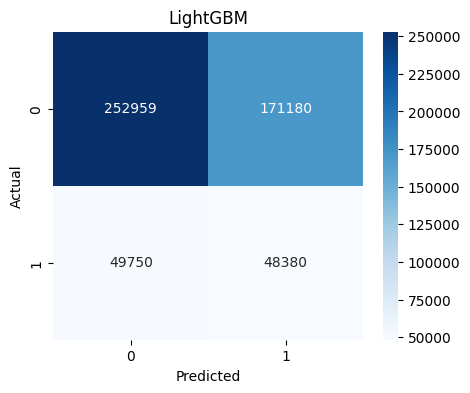

In [12]:
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.015,
    num_leaves=80,
    max_depth=-1,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
)

lgb_model.fit(X_fit, y_fit)

y_prob_lgb_val = lgb_model.predict_proba(X_val)[:, 1]
lgb_threshold = best_threshold_from_validation(y_val, y_prob_lgb_val)

y_prob_lgb = lgb_model.predict_proba(X_test_np)[:, 1]
y_pred_lgb = (y_prob_lgb >= lgb_threshold).astype(int)

results_lgb = evaluate_model(y_test_np, y_prob_lgb, threshold=lgb_threshold, model_name="LightGBM")
plot_cm(y_test_np, y_pred_lgb, "LightGBM")


In [13]:
results = [results_lr, results_lgb]
results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)
print("MODEL COMPARISON")
print(tabulate(results_df, headers="keys", tablefmt="fancy_grid", showindex=False))
results_df


MODEL COMPARISON
╒═════════════════════╤═════════════╤════════════╤═════════════╤══════════╤════════╤═══════════╕
│ Model               │   Threshold │   Accuracy │   Precision │   Recall │     F1 │   ROC-AUC │
╞═════════════════════╪═════════════╪════════════╪═════════════╪══════════╪════════╪═══════════╡
│ Logistic Regression │        0.48 │     0.2183 │      0.1916 │   0.9816 │ 0.3206 │    0.6177 │
├─────────────────────┼─────────────┼────────────┼─────────────┼──────────┼────────┼───────────┤
│ LightGBM            │        0.24 │     0.577  │      0.2203 │   0.493  │ 0.3046 │    0.5643 │
╘═════════════════════╧═════════════╧════════════╧═════════════╧══════════╧════════╧═══════════╛


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.48,0.2183,0.1916,0.9816,0.3206,0.6177
1,LightGBM,0.24,0.5770,0.2203,0.4930,0.3046,0.5643


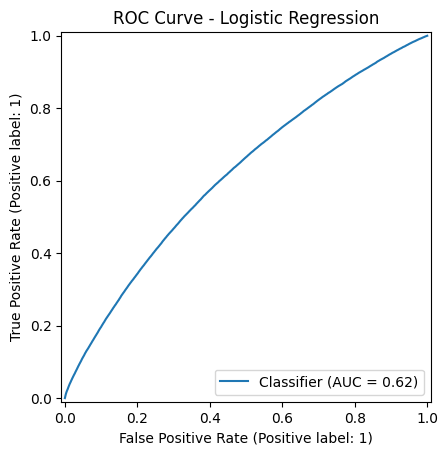

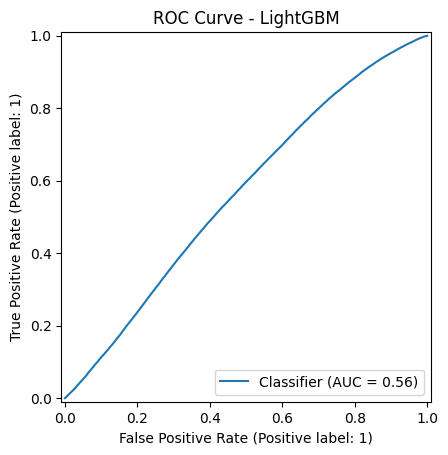

In [14]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test_np, y_prob_lr)
plt.title("ROC Curve - Logistic Regression")
plt.show()

RocCurveDisplay.from_predictions(y_test_np, y_prob_lgb)
plt.title("ROC Curve - LightGBM")
plt.show()


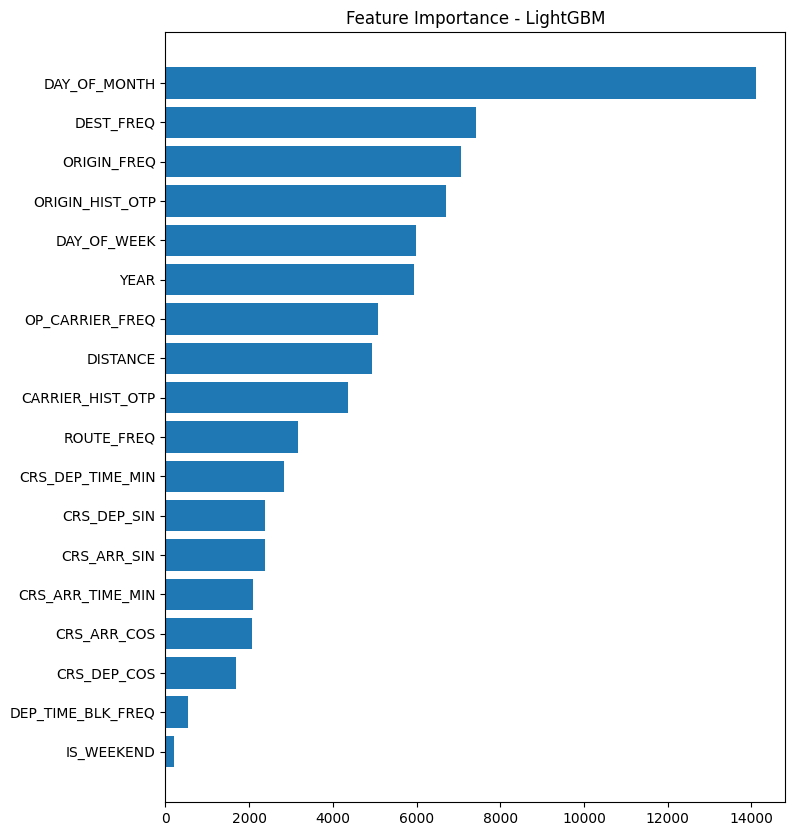

In [15]:
importances = lgb_model.feature_importances_
features = X_train.columns

indices = np.argsort(importances)

plt.figure(figsize=(8, 10))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("Feature Importance - LightGBM")
plt.show()
